In [4]:
# ============================================================
# STEP 1: DOWNLOAD DATASET FROM GITHUB
# ============================================================

!git clone https://github.com/qubiit/NIFTY-50-Stock-Market-Data.git

print("Dataset downloaded successfully!")

fatal: destination path 'NIFTY-50-Stock-Market-Data' already exists and is not an empty directory.
Dataset downloaded successfully!


In [5]:
# ============================================================
# STEP 2: CHECK DATASET
# ============================================================

import os

data_folder = "/content/NIFTY-50-Stock-Market-Data/data"

files = os.listdir(data_folder)

print("Files found:")
print(files)

print("\nNumber of CSV files:", len(files))

Files found:
['2016.csv', '2019.csv', '2023.csv', '2022.csv', '2021.csv', '2026.csv', '2018.csv', '2020.csv', '2025.csv', '2017.csv', '2024.csv']

Number of CSV files: 11


In [3]:
# ============================================================
# STEP 3: COMBINE ALL YEARLY CSV FILES
# ============================================================

import pandas as pd
import glob
import os

csv_files = glob.glob(
    "/content/NIFTY-50-Stock-Market-Data/data/*.csv"
)

print("CSV files found:", len(csv_files))

all_data = []

for file in csv_files:

    print("Reading:", os.path.basename(file))

    temp = pd.read_csv(file)

    all_data.append(temp)

# Combine everything
data = pd.concat(
    all_data,
    ignore_index=True
)

print("\n================================")
print("COMBINED DATASET")
print("================================")

print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

display(data.head())

CSV files found: 11
Reading: 2016.csv
Reading: 2019.csv
Reading: 2023.csv
Reading: 2022.csv
Reading: 2021.csv
Reading: 2026.csv
Reading: 2018.csv
Reading: 2020.csv
Reading: 2025.csv
Reading: 2017.csv
Reading: 2024.csv

COMBINED DATASET
Rows: 112790
Columns: 10


,Unnamed: 0,timestamp,symbol,open,high,low,close,previous_close,volume,turnover
0,0,2016-01-01,ADANIENT,83.60,90.7,82.35,90.10,83.40,5974246,5.218478e+08
1,1,2016-01-01,ADANIPORTS,261.00,268.3,260.10,267.55,260.90,1347893,3.574478e+08
2,2,2016-01-01,APOLLOHOSP,1458.50,1480.0,1449.00,1460.80,1466.45,107024,1.571439e+08
3,3,2016-01-01,ASIANPAINT,882.00,885.6,876.90,878.75,883.55,294006,2.589019e+08
4,4,2016-01-01,AXISBANK,449.75,452.9,445.55,449.90,449.10,3345654,1.504733e+09


In [ ]:
# ============================================================
# STEP 4: CLEAN DATA
# ============================================================

# Convert timestamp to date
data["timestamp"] = pd.to_datetime(
    data["timestamp"]
)

# Sort data
data = data.sort_values(
    ["symbol", "timestamp"]
)

# Remove duplicate rows
data = data.drop_duplicates()

# Remove rows without closing price
data = data.dropna(
    subset=["close"]
)

print("Cleaned dataset")

print("Rows:", len(data))
print("Stocks:", data["symbol"].nunique())

print("\nStocks available:")
print(
    data["symbol"]
    .nunique()
)

display(data.head())

Cleaned dataset
Rows: 112790
Stocks: 50

Stocks available:
50


,Unnamed: 0,timestamp,symbol,open,high,low,close,previous_close,volume,turnover
0,0,2016-01-01,ADANIENT,83.60,90.70,82.35,90.10,83.40,5974246,5.218478e+08
42,42,2016-01-04,ADANIENT,89.50,92.05,84.25,85.10,90.10,5126957,4.510840e+08
84,84,2016-01-05,ADANIENT,85.65,89.60,84.20,88.60,85.10,5341021,4.656601e+08
126,126,2016-01-06,ADANIENT,88.00,88.95,85.30,86.25,88.60,3865229,3.362317e+08
168,168,2016-01-07,ADANIENT,84.90,84.90,78.00,79.95,86.25,4859987,3.965048e+08


In [ ]:
# ============================================================
# STEP 5: CALCULATE DAILY RETURNS
# ============================================================

data["daily_return"] = (
    data
    .groupby("symbol")["close"]
    .pct_change()
)

# Remove missing returns
data = data.dropna(
    subset=["daily_return"]
)

print("Daily returns calculated!")

display(
    data[
        [
            "timestamp",
            "symbol",
            "close",
            "daily_return"
        ]
    ].head(20)
)

Daily returns calculated!


,timestamp,symbol,close,daily_return
42,2016-01-04,ADANIENT,85.10,-0.055494
84,2016-01-05,ADANIENT,88.60,0.041128
126,2016-01-06,ADANIENT,86.25,-0.026524
168,2016-01-07,ADANIENT,79.95,-0.073043
210,2016-01-08,ADANIENT,82.00,0.025641
252,2016-01-11,ADANIENT,82.35,0.004268
294,2016-01-12,ADANIENT,80.80,-0.018822
336,2016-01-13,ADANIENT,80.85,0.000619
378,2016-01-14,ADANIENT,77.80,-0.037724
420,2016-01-15,ADANIENT,74.40,-0.043702


In [ ]:
# ============================================================
# STEP 6: CREATE STOCK RETURN MATRIX
# ============================================================

returns = data.pivot_table(
    index="timestamp",
    columns="symbol",
    values="daily_return"
)

print("Return matrix created!")

print(
    "Rows (dates):",
    returns.shape[0]
)

print(
    "Columns (stocks):",
    returns.shape[1]
)

display(
    returns.head()
)

Return matrix created!
Rows (dates): 2483
Columns (stocks): 50


symbol,ADANIENT,ADANIPORTS,APOLLOHOSP,ASIANPAINT,AXISBANK,BAJAJ-AUTO,BAJAJFINSV,BAJFINANCE,BEL,BHARTIARTL,...,SUNPHARMA,TATACONSUM,TATASTEEL,TCS,TECHM,TITAN,TMPV,TRENT,ULTRACEMCO,WIPRO
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-04,-0.055494,-0.035881,-0.007325,0.002333,-0.025561,-0.013761,-0.012249,-0.007120,-0.004143,-0.040235,...,-0.020170,NaN,-0.001943,-0.019368,-0.007019,-0.001846,NaN,-0.025583,-0.026505,0.002246
2016-01-05,0.041128,-0.008723,0.012689,0.022536,-0.004448,0.007651,-0.006890,-0.009021,-0.002847,-0.010251,...,0.001752,NaN,0.067731,-0.008715,0.010651,-0.010529,NaN,-0.015542,-0.005856,-0.001434
2016-01-06,-0.026524,-0.015252,-0.008955,-0.015822,-0.013174,-0.006734,-0.003828,0.018240,-0.009333,-0.003865,...,-0.010681,NaN,-0.020233,0.013900,0.006131,0.000431,NaN,-0.017036,0.000823,-0.003232
2016-01-07,-0.073043,-0.027006,-0.040334,-0.015851,-0.049803,-0.026655,-0.005932,-0.000156,-0.044037,0.000466,...,-0.010291,NaN,-0.070140,-0.004346,-0.027233,-0.010924,NaN,-0.016152,-0.024714,-0.009458
2016-01-08,0.025641,-0.014694,0.005656,0.002579,0.010874,-0.017939,0.038063,0.034096,0.003285,0.004653,...,0.013205,NaN,0.014806,0.011112,0.022220,0.011481,NaN,0.052418,0.014057,0.010821


In [ ]:
# ============================================================
# STEP 7: HANDLE MISSING VALUES
# ============================================================

print(
    "Missing values before:",
    returns.isnull().sum().sum()
)

# Fill missing values using column median
returns = returns.fillna(
    returns.median()
)

print(
    "Missing values after:",
    returns.isnull().sum().sum()
)

Missing values before: 11410
Missing values after: 0


In [ ]:
# ============================================================
# STEP 8: HANDLE OUTLIERS
# ============================================================

lower = returns.quantile(0.01)
upper = returns.quantile(0.99)

returns_clean = returns.clip(
    lower=lower,
    upper=upper,
    axis="columns"
)

print("Outliers capped successfully.")

Outliers capped successfully.


In [ ]:
# ============================================================
# STEP 9: STANDARDIZATION
# ============================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(
    returns_clean
)

print("Standardization completed.")

print(
    "Data shape:",
    X_scaled.shape
)

Standardization completed.
Data shape: (2483, 50)


In [ ]:
# ============================================================
# STEP 10: PCA
# ============================================================

from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(
    X_scaled
)

print("PCA completed!")

print(
    "Original dimensions:",
    X_scaled.shape[1]
)

print(
    "PCA dimensions:",
    X_pca.shape[1]
)

PCA completed!
Original dimensions: 50
PCA dimensions: 50


In [ ]:
# ============================================================
# STEP 11: EXPLAINED VARIANCE
# ============================================================

explained_variance = (
    pca.explained_variance_ratio_
    * 100
)

cumulative_variance = (
    explained_variance.cumsum()
)

pca_results = pd.DataFrame({

    "PC":
        [
            f"PC{i+1}"
            for i in range(
                len(explained_variance)
            )
        ],

    "Explained_Variance_%":
        explained_variance,

    "Cumulative_Variance_%":
        cumulative_variance
})

display(
    pca_results.head(15)
)

,PC,Explained_Variance_%,Cumulative_Variance_%
0,PC1,25.664538,25.664538
1,PC2,5.219885,30.884422
2,PC3,3.946913,34.831336
3,PC4,3.299305,38.130641
4,PC5,3.031034,41.161675
5,PC6,2.578541,43.740216
6,PC7,2.298664,46.038880
7,PC8,2.216529,48.255409
8,PC9,2.104456,50.359865
9,PC10,2.038019,52.397884


In [ ]:
# ============================================================
# STEP 12: AUTOMATIC COMPONENT SELECTION
# ============================================================

threshold = 85

n_components = (
    cumulative_variance >= threshold
).argmax() + 1

print(
    f"Components needed for "
    f"{threshold}% variance:",
    n_components
)

print(
    f"Variance preserved:",
    f"{cumulative_variance[n_components-1]:.2f}%"
)

Components needed for 85% variance: 33
Variance preserved: 85.99%


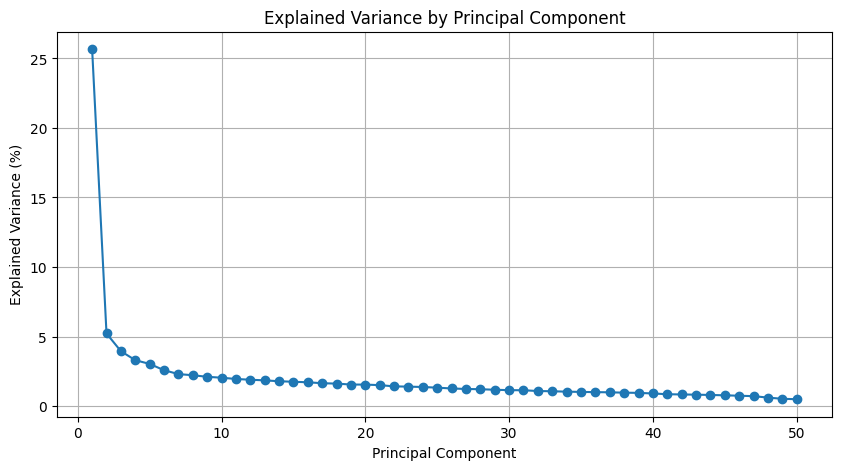

In [ ]:
# ============================================================
# GRAPH 1: EXPLAINED VARIANCE
# ============================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(explained_variance)+1),
    explained_variance,
    marker="o"
)

plt.xlabel("Principal Component")
plt.ylabel("Explained Variance (%)")

plt.title(
    "Explained Variance by Principal Component"
)

plt.grid(True)

plt.show()

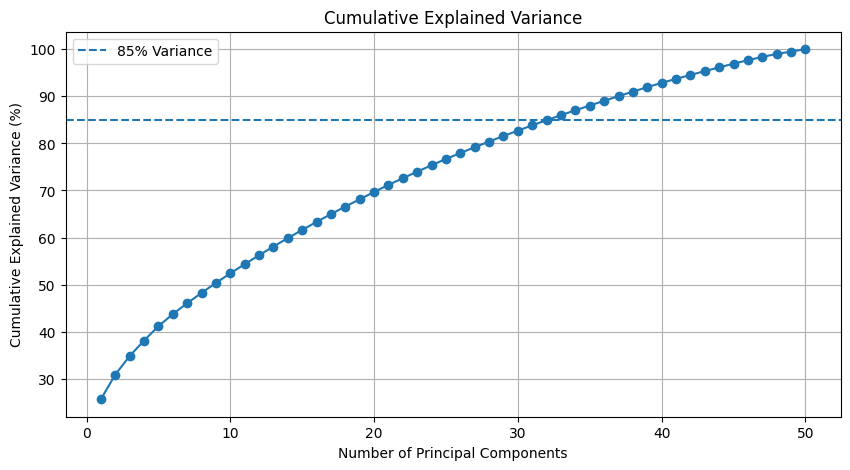

In [ ]:
# ============================================================
# GRAPH 2: CUMULATIVE VARIANCE
# ============================================================

plt.figure(figsize=(10,5))

plt.plot(
    range(1, len(cumulative_variance)+1),
    cumulative_variance,
    marker="o"
)

plt.axhline(
    y=85,
    linestyle="--",
    label="85% Variance"
)

plt.xlabel("Number of Principal Components")

plt.ylabel(
    "Cumulative Explained Variance (%)"
)

plt.title(
    "Cumulative Explained Variance"
)

plt.legend()

plt.grid(True)

plt.show()

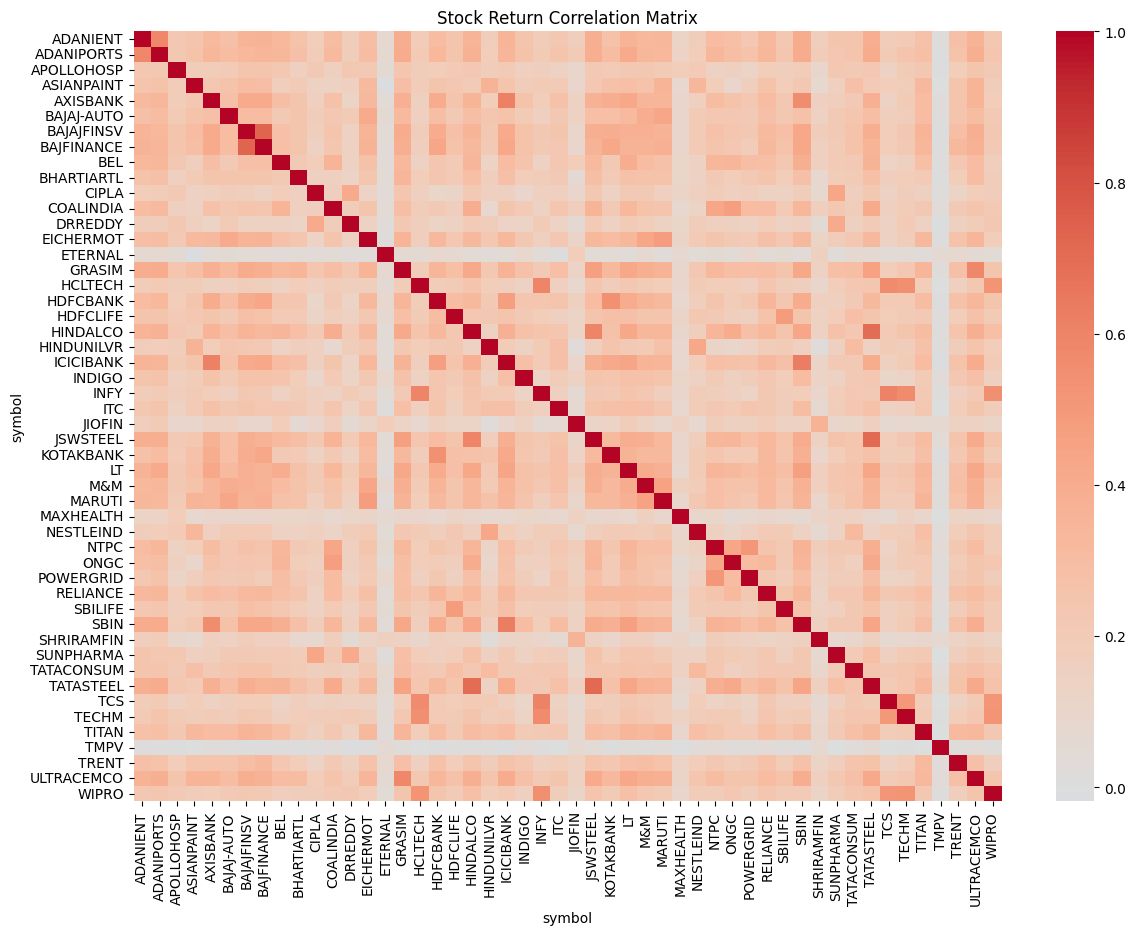

In [ ]:
# ============================================================
# GRAPH 3: CORRELATION HEATMAP
# ============================================================

import seaborn as sns

plt.figure(figsize=(14,10))

sns.heatmap(
    returns_clean.corr(),
    cmap="coolwarm",
    center=0
)

plt.title(
    "Stock Return Correlation Matrix"
)

plt.show()

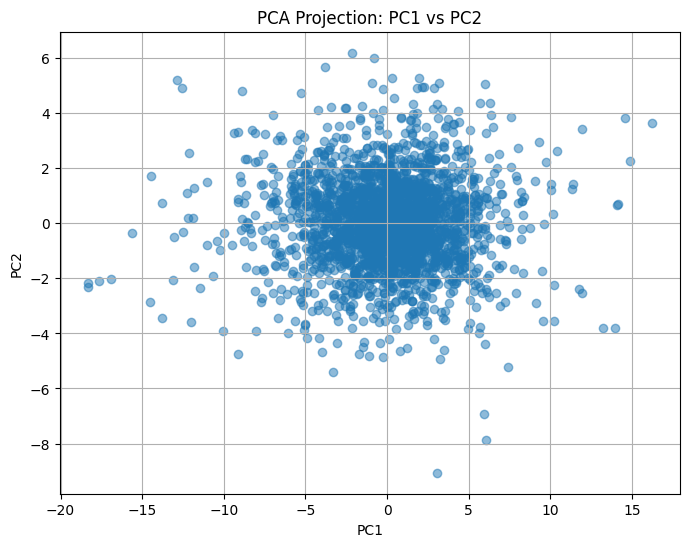

In [ ]:
# ============================================================
# GRAPH 4: PC1 vs PC2
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.5
)

plt.xlabel("PC1")

plt.ylabel("PC2")

plt.title(
    "PCA Projection: PC1 vs PC2"
)

plt.grid(True)

plt.show()

In [ ]:
# ============================================================
# STEP 13: PCA LOADINGS
# ============================================================

loadings = pd.DataFrame(

    pca.components_.T,

    columns=[
        f"PC{i+1}"
        for i in range(
            len(pca.components_)
        )
    ],

    index=returns_clean.columns
)

display(
    loadings.iloc[:, :n_components]
)

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33
symbol,,,,,,,,,,,,,,,,,,,,,
ADANIENT,0.165357,-0.064656,-0.054126,0.013466,0.038130,0.048255,0.140183,0.030725,-0.069181,0.257860,...,-0.086755,0.048272,0.027961,0.039788,-0.031995,-0.054792,0.030325,0.079982,-0.019668,-0.038460
ADANIPORTS,0.171313,-0.056130,-0.071715,0.004079,0.054956,0.017843,0.107286,0.001775,-0.046789,0.253659,...,-0.091937,0.115755,0.015786,0.017641,0.058828,0.005500,-0.115951,-0.084825,-0.038989,0.042522
APOLLOHOSP,0.112573,0.060186,0.046408,0.194243,0.022904,0.178871,0.071560,0.044588,-0.130720,0.156152,...,0.060354,-0.182050,0.153671,0.103844,-0.033044,-0.087748,0.047922,-0.087156,0.009901,-0.052415
ASIANPAINT,0.130725,0.039249,0.278886,0.117987,-0.004685,-0.187359,0.081189,-0.042297,0.063119,0.063612,...,-0.032447,-0.359545,0.289249,-0.305800,-0.147820,0.178216,-0.044502,-0.219855,0.170461,0.051464
AXISBANK,0.168284,-0.136005,0.054032,-0.188208,-0.031854,0.165138,-0.169198,-0.090892,0.131767,0.025698,...,0.120828,-0.079492,0.100287,0.035769,0.099654,0.002212,-0.017312,-0.017093,-0.100939,0.088189
BAJAJ-AUTO,0.146862,-0.030983,0.108237,0.099107,0.017580,-0.075212,0.249717,-0.180840,-0.103891,-0.333043,...,0.108211,0.252202,-0.035004,-0.073107,0.352379,0.176316,0.325662,-0.063956,0.237635,0.350255
BAJAJFINSV,0.175780,-0.082175,0.151806,-0.123094,-0.010098,0.169062,0.044201,0.011903,-0.037819,-0.046789,...,-0.068678,-0.089777,-0.077723,-0.026102,0.137980,0.064850,0.011512,-0.041171,0.083053,-0.004587
BAJFINANCE,0.173424,-0.085506,0.177379,-0.143075,-0.001544,0.193238,0.047432,-0.031823,-0.051580,-0.016611,...,-0.043324,-0.053925,-0.116572,-0.050900,0.110077,0.046732,-0.001139,0.023985,0.028945,-0.040588
BEL,0.147104,-0.104576,-0.148875,0.037011,0.037275,-0.085031,-0.060941,-0.061893,-0.114783,0.166347,...,-0.271781,0.039518,-0.308403,-0.164712,-0.203977,0.290816,0.176857,0.180580,-0.099304,0.149630


In [ ]:
# ============================================================
# STEP 14: TOP STOCKS FOR EACH COMPONENT
# ============================================================

for pc in range(
    min(n_components, 10)
):

    pc_name = f"PC{pc+1}"

    top_stocks = (
        loadings[pc_name]
        .abs()
        .sort_values(
            ascending=False
        )
        .head(10)
    )

    print("\n================================")
    print(pc_name)
    print("================================")

    for stock in top_stocks.index:

        loading = loadings.loc[
            stock,
            pc_name
        ]

        print(
            f"{stock}: {loading:.4f}"
        )


PC1
TATASTEEL: 0.1864
LT: 0.1847
GRASIM: 0.1828
SBIN: 0.1828
JSWSTEEL: 0.1813
HINDALCO: 0.1795
ULTRACEMCO: 0.1770
ICICIBANK: 0.1762
BAJAJFINSV: 0.1758
BAJFINANCE: 0.1734

PC2
INFY: 0.4139
TCS: 0.4042
HCLTECH: 0.4030
TECHM: 0.3716
WIPRO: 0.3571
SBIN: -0.1554
AXISBANK: -0.1360
ICICIBANK: -0.1301
DRREDDY: 0.1234
NESTLEIND: 0.1151

PC3
HINDUNILVR: 0.3097
ONGC: -0.3024
COALINDIA: -0.2862
ASIANPAINT: 0.2789
NTPC: -0.2396
NESTLEIND: 0.2372
TATASTEEL: -0.2288
HINDALCO: -0.2085
KOTAKBANK: 0.1837
POWERGRID: -0.1829

PC4
CIPLA: 0.4016
DRREDDY: 0.3844
SUNPHARMA: 0.3538
NESTLEIND: 0.2301
ICICIBANK: -0.2114
HDFCBANK: -0.2060
HINDUNILVR: 0.1995
APOLLOHOSP: 0.1942
AXISBANK: -0.1882
MAXHEALTH: 0.1810

PC5
JIOFIN: 0.5084
SHRIRAMFIN: 0.4785
ETERNAL: 0.3841
MAXHEALTH: 0.2096
HINDALCO: -0.1692
JSWSTEEL: -0.1680
TMPV: 0.1666
HDFCLIFE: 0.1637
SUNPHARMA: -0.1614
TATASTEEL: -0.1610

PC6
CIPLA: 0.2863
DRREDDY: 0.2840
SUNPHARMA: 0.2751
POWERGRID: -0.2614
NESTLEIND: -0.2488
NTPC: -0.2472
HINDUNILVR: -0.2192
ONGC

In [ ]:
# ============================================================
# STEP 15: REDUCED DATASET
# ============================================================

pca_final = PCA(
    n_components=n_components
)

X_reduced = pca_final.fit_transform(
    X_scaled
)

reduced_df = pd.DataFrame(
    X_reduced,
    columns=[
        f"PC{i+1}"
        for i in range(n_components)
    ],
    index=returns_clean.index
)

print("Reduced dataset:")

display(
    reduced_df.head()
)

Reduced dataset:


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC24,PC25,PC26,PC27,PC28,PC29,PC30,PC31,PC32,PC33
timestamp,,,,,,,,,,,,,,,,,,,,,
2016-01-04,-6.443873,0.242544,-0.004289,0.286743,0.658686,-1.585036,0.406842,0.654206,-1.036437,-1.293361,...,-0.633764,-1.799431,0.418485,-0.208937,0.034148,1.616086,0.025798,0.214638,-1.274607,0.023705
2016-01-05,0.216256,-0.409164,-1.324306,0.116582,-0.978323,0.219843,1.469182,1.997873,-0.067178,0.054537,...,-0.266799,-1.069900,0.226895,0.243303,-0.029543,0.804261,0.262737,-1.297933,0.600868,-0.413870
2016-01-06,-2.480933,1.198433,0.359150,0.027257,0.877920,0.258102,-0.124617,-0.084405,-0.621830,-0.964875,...,-0.312139,0.196519,-0.813962,1.176346,0.091135,-0.479170,-1.014941,1.076133,-0.823939,2.089985
2016-01-07,-8.867122,0.147881,0.890444,-0.822575,1.847086,0.840914,-0.833562,0.767457,-0.653404,0.149473,...,-0.277277,0.666396,0.599357,0.187314,0.463254,0.123816,-1.136950,0.377673,1.275833,0.163334
2016-01-08,2.116453,0.596488,-0.262674,-1.283754,0.183598,0.176816,0.230654,-0.229236,-0.013958,0.968144,...,0.353842,-0.896452,0.280770,1.351133,0.203257,0.398234,0.322637,1.379064,-0.989756,-1.102760


In [ ]:
# ============================================================
# STEP 16: SAVE RESULTS
# ============================================================

reduced_df.to_csv(
    "/content/PCA_Reduced_Data.csv"
)

pca_results.to_csv(
    "/content/PCA_Explained_Variance.csv",
    index=False
)

loadings.to_csv(
    "/content/PCA_Loadings.csv"
)

print("Files created:")
print("1. PCA_Reduced_Data.csv")
print("2. PCA_Explained_Variance.csv")
print("3. PCA_Loadings.csv")

Files created:
1. PCA_Reduced_Data.csv
2. PCA_Explained_Variance.csv
3. PCA_Loadings.csv


In [ ]:
from google.colab import files

files.download(
    "/content/PCA_Reduced_Data.csv"
)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>